In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings 
warnings.filterwarnings('ignore')

In [2]:
df= pd.read_csv('heart.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


# EDA 

In [3]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [4]:
df.shape

(918, 12)

In [5]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [7]:
df.duplicated().sum()

0

In [8]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


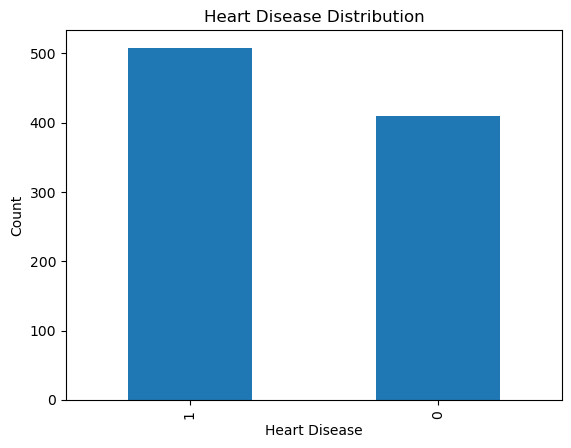

In [9]:
df['HeartDisease'].value_counts().plot(kind="bar")

plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.title("Heart Disease Distribution")

plt.show()

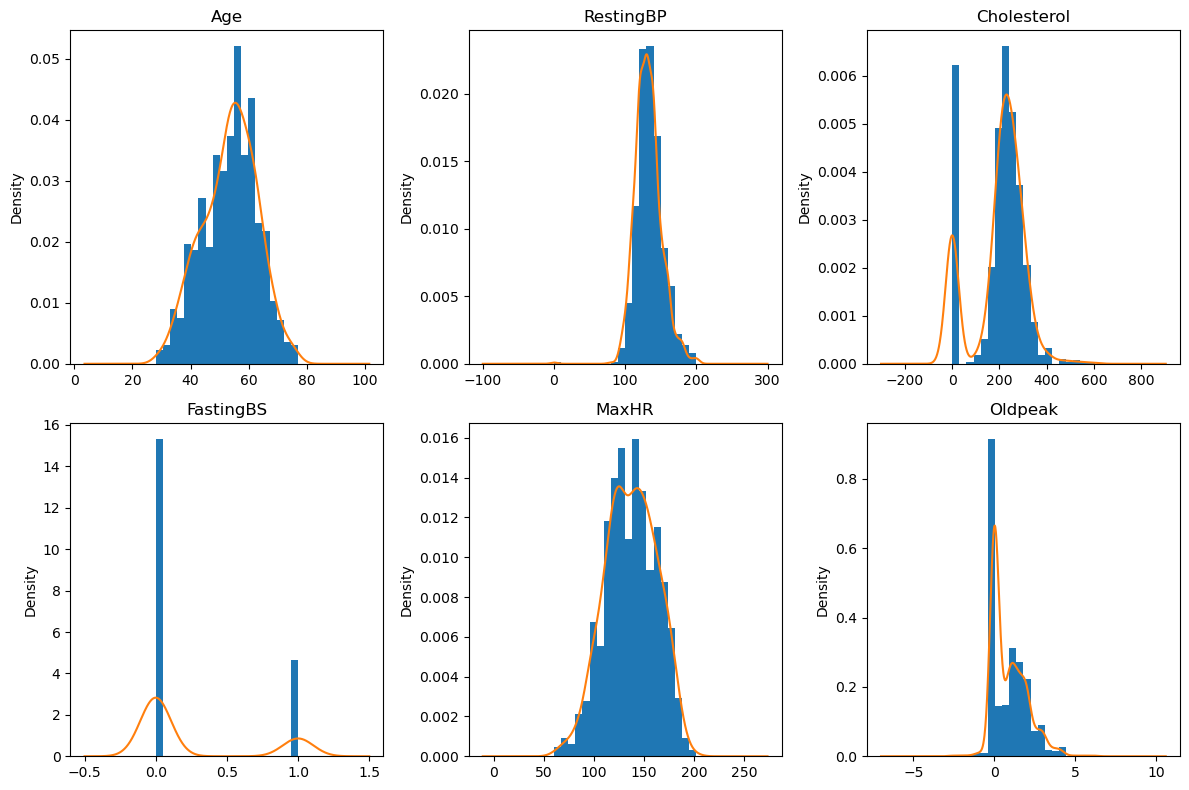

In [10]:


numerical_columns = [
    'Age',
    'RestingBP',
    'Cholesterol',
    'FastingBS',
    'MaxHR',
    'Oldpeak'
]

fig, axes = plt.subplots(2, 3, figsize=(12,8))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    df[col].plot.hist(
        ax=axes[i],
        bins=20,
        density=True
    )

    df[col].plot.kde(ax=axes[i])

    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [11]:
# now check count of 0 
columns = ['RestingBP', 'Cholesterol']

for col in columns:
    print(col, ":", (df[col] == 0).sum())
for col in columns:
    percentage = ((df[col] == 0).sum()/len(df))*100
    print(f"{col}: {percentage:.2f}%")

RestingBP : 1
Cholesterol : 172
RestingBP: 0.11%
Cholesterol: 18.74%


In [12]:
# Replace invalid values with median

df["RestingBP"] = df["RestingBP"].replace(
    0,
    df["RestingBP"].median()
)

df["Cholesterol"] = df["Cholesterol"].replace(
    0,
    df["Cholesterol"].median()
)

In [13]:
print("RestingBP :", (df["RestingBP"]==0).sum())
print("Cholesterol :", (df["Cholesterol"]==0).sum())

RestingBP : 0
Cholesterol : 0


In [14]:
print(df.duplicated().sum())

0


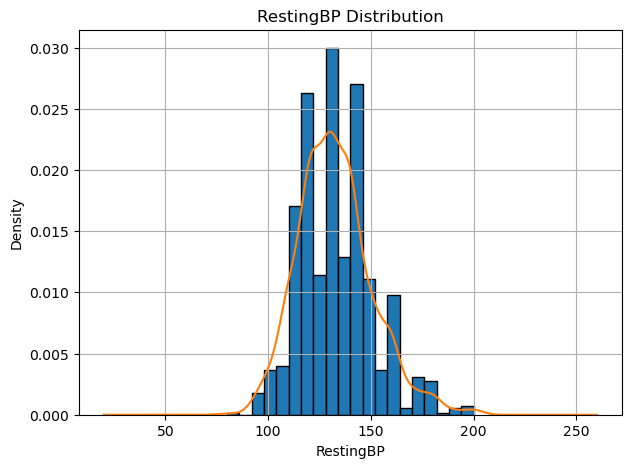

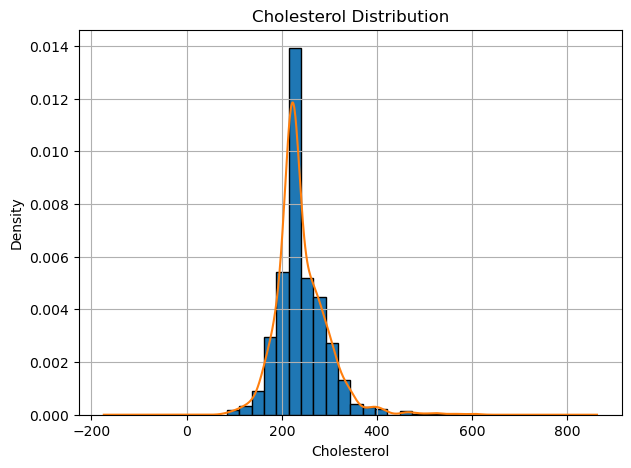

In [15]:
import matplotlib.pyplot as plt

columns = ['RestingBP', 'Cholesterol']

for col in columns:
    
    plt.figure(figsize=(7,5))

    plt.hist(
        df[col],
        bins=20,
        density=True,
        edgecolor='black'   # border
    )

    df[col].plot.kde()

    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.ylabel("Density")

    plt.grid()

    plt.show()

In [16]:
# Now for categorical data 

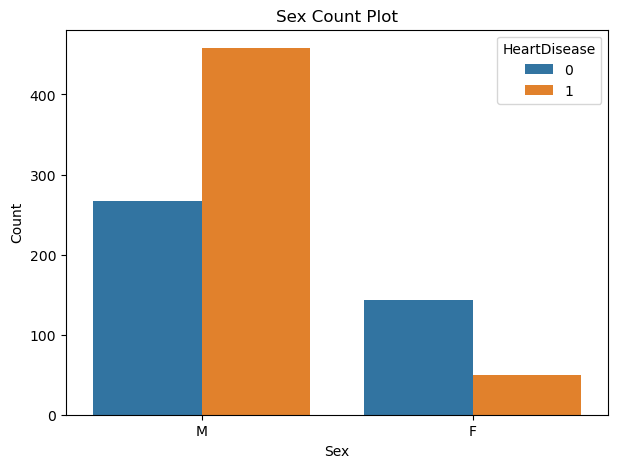

In [17]:


plt.figure(figsize=(7,5))

sns.countplot(x=df['Sex'], hue=df['HeartDisease'])

plt.title('Sex Count Plot')
plt.xlabel('Sex')
plt.ylabel('Count')

plt.show()

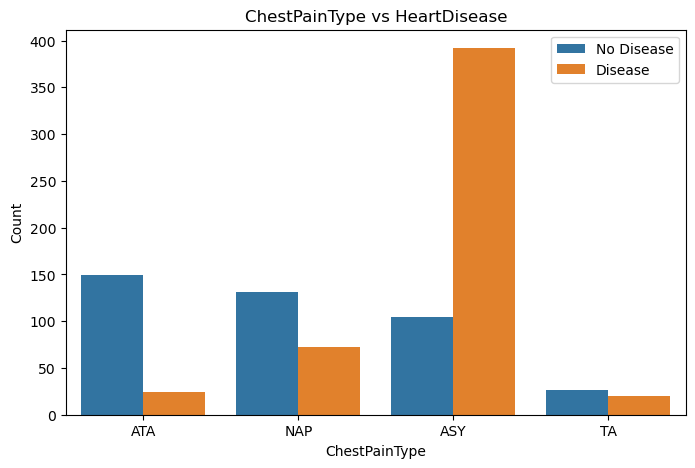

In [18]:


plt.figure(figsize=(8,5))

sns.countplot(
    x=df['ChestPainType'],
    hue=df['HeartDisease']
)

plt.title('ChestPainType vs HeartDisease')
plt.xlabel('ChestPainType')
plt.ylabel('Count')

plt.legend(['No Disease', 'Disease'])

plt.show()

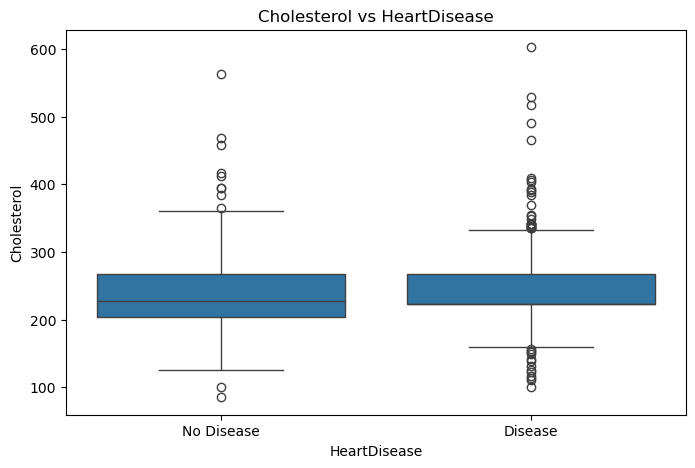

In [19]:


plt.figure(figsize=(8,5))

sns.boxplot(
    x='HeartDisease',
    y='Cholesterol',
    data=df
)

plt.title('Cholesterol vs HeartDisease')
plt.xlabel('HeartDisease')
plt.ylabel('Cholesterol')

plt.xticks([0,1], ['No Disease', 'Disease'])

plt.show()

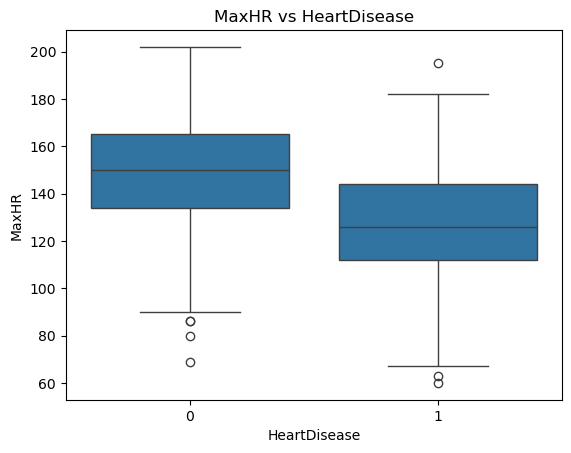

In [20]:
sns.boxplot(x='HeartDisease', y='MaxHR', data=df)

plt.title('MaxHR vs HeartDisease')

plt.show()

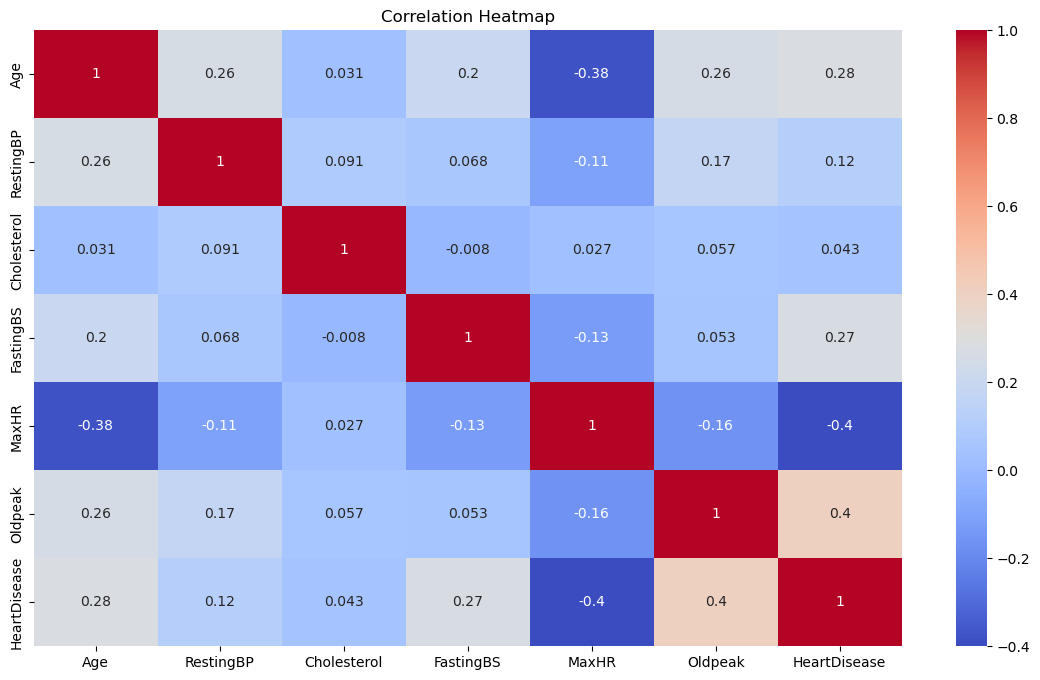

In [21]:


plt.figure(figsize=(14,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

# Data preprocessing and data cleaning 

In [22]:
df = pd.get_dummies(
    df,
    columns=[
        'Sex',
        'ChestPainType',
        'RestingECG',
        'ExerciseAngina',
        'ST_Slope'
    ],
    drop_first=True
)

print(df.head())

   Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  HeartDisease  \
0   40        140          289          0    172      0.0             0   
1   49        160          180          0    156      1.0             1   
2   37        130          283          0     98      0.0             0   
3   48        138          214          0    108      1.5             1   
4   54        150          195          0    122      0.0             0   

   Sex_M  ChestPainType_ATA  ChestPainType_NAP  ChestPainType_TA  \
0   True               True              False             False   
1  False              False               True             False   
2   True               True              False             False   
3  False              False              False             False   
4   True              False               True             False   

   RestingECG_Normal  RestingECG_ST  ExerciseAngina_Y  ST_Slope_Flat  \
0               True          False             False          False

In [23]:
df = df.astype(int)

print(df.head())

   Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  HeartDisease  \
0   40        140          289          0    172        0             0   
1   49        160          180          0    156        1             1   
2   37        130          283          0     98        0             0   
3   48        138          214          0    108        1             1   
4   54        150          195          0    122        0             0   

   Sex_M  ChestPainType_ATA  ChestPainType_NAP  ChestPainType_TA  \
0      1                  1                  0                 0   
1      0                  0                  1                 0   
2      1                  1                  0                 0   
3      0                  0                  0                 0   
4      1                  0                  1                 0   

   RestingECG_Normal  RestingECG_ST  ExerciseAngina_Y  ST_Slope_Flat  \
0                  1              0                 0              0

In [24]:
# for numerical 
corr = df.corr(numeric_only=True)

print(corr['HeartDisease'].sort_values())

ST_Slope_Up         -0.622164
ChestPainType_ATA   -0.401924
MaxHR               -0.400421
ChestPainType_NAP   -0.212964
RestingECG_Normal   -0.091580
ChestPainType_TA    -0.054790
Cholesterol          0.042988
RestingECG_ST        0.102527
RestingBP            0.117798
FastingBS            0.267291
Age                  0.282039
Sex_M                0.305445
Oldpeak              0.392385
ExerciseAngina_Y     0.494282
ST_Slope_Flat        0.554134
HeartDisease         1.000000
Name: HeartDisease, dtype: float64


In [25]:
# for categorical 
from scipy.stats import chi2_contingency
import pandas as pd

# Categorical / encoded features
cat_features = [
    'Sex_M',
    'ChestPainType_ATA',
    'ChestPainType_NAP',
    'ChestPainType_TA',
    'RestingECG_Normal',
    'RestingECG_ST',
    'ExerciseAngina_Y',
    'ST_Slope_Flat',
    'ST_Slope_Up',
    'FastingBS'
]

chi2_result = {}

for col in cat_features:

    # Contingency table
    contingency = pd.crosstab(
        df[col],
        df['HeartDisease']
    )

    # Chi-square test
    chi2_stat, p_value, dof, expected = chi2_contingency(contingency)

    # Decision
    if p_value < 0.05:
        decision = "Reject H0 → Important feature"
    else:
        decision = "Fail to reject H0 → Not important"

    chi2_result[col] = {
        "Chi2_stat": chi2_stat,
        "P_value": p_value,
        "Decision": decision
    }

# Convert into dataframe
result = pd.DataFrame(chi2_result).T

print(result)

                    Chi2_stat   P_value                           Decision
Sex_M               84.145101       0.0      Reject H0 → Important feature
ChestPainType_ATA  146.236323       0.0      Reject H0 → Important feature
ChestPainType_NAP   40.608711       0.0      Reject H0 → Important feature
ChestPainType_TA     2.273802  0.131577  Fail to reject H0 → Not important
RestingECG_Normal    7.327532  0.006791      Reject H0 → Important feature
RestingECG_ST        9.135266  0.002507      Reject H0 → Important feature
ExerciseAngina_Y   222.259383       0.0      Reject H0 → Important feature
ST_Slope_Flat      279.659914       0.0      Reject H0 → Important feature
ST_Slope_Up        352.823905       0.0      Reject H0 → Important feature
FastingBS           64.320679       0.0      Reject H0 → Important feature


In [26]:
df.shape

(918, 16)

In [27]:
df.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1


# Train Test Split 


In [28]:
x = df.drop('HeartDisease', axis=1)

y = df['HeartDisease']

In [29]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [30]:
print("X Train:", x_train.shape)
print("X Test :", x_test.shape)

print("Y Train:", y_train.shape)
print("Y Test :", y_test.shape)

X Train: (734, 15)
X Test : (184, 15)
Y Train: (734,)
Y Test : (184,)


In [31]:
# Scaling 

from sklearn.preprocessing import StandardScaler

num_cols = [
    'Age',
    'RestingBP',
    'Cholesterol',
    'MaxHR',
    'Oldpeak'
]

scaler = StandardScaler()

x_train[num_cols] = scaler.fit_transform(x_train[num_cols])

x_test[num_cols] = scaler.transform(x_test[num_cols])

# Compare models in dictionary form 

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

In [33]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(random_state=42)
}

In [34]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

results = []

for name, model in models.items():

    # Train
    model.fit(x_train, y_train)

    # Prediction
    y_pred = model.predict(x_test)

    # Metrics
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

In [35]:
import pandas as pd

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.869565   0.882353  0.882353  0.882353
2          Naive Bayes  0.869565   0.906250  0.852941  0.878788
1                  KNN  0.853261   0.871287  0.862745  0.866995
3                  SVM  0.853261   0.871287  0.862745  0.866995


# Best model 

In [36]:
best_model = results_df.iloc[0]

print(best_model)

Model        Logistic Regression
Accuracy                0.869565
Precision               0.882353
Recall                  0.882353
F1 Score                0.882353
Name: 0, dtype: object


In [37]:
from sklearn.model_selection import cross_val_score

for name, model in models.items():

    scores = cross_val_score(
        model,
        x,
        y,
        cv=5,
        scoring='accuracy'
    )

    print(f"{name}: {scores.mean():.4f}")

Logistic Regression: 0.8376
KNN: 0.6231
Naive Bayes: 0.8322
SVM: 0.6798


# Check Underfitting and Overfitting 

In [38]:
from sklearn.metrics import accuracy_score

results = []

for name, model in models.items():

    model.fit(x_train, y_train)

    # Train prediction
    y_train_pred = model.predict(x_train)

    # Test prediction
    y_test_pred = model.predict(x_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    results.append({
        "Model": name,
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Difference": train_acc - test_acc
    })

results_df = pd.DataFrame(results)

print(results_df)

                 Model  Train Accuracy  Test Accuracy  Difference
0  Logistic Regression        0.859673       0.869565   -0.009892
1                  KNN        0.880109       0.853261    0.026848
2          Naive Bayes        0.844687       0.869565   -0.024879
3                  SVM        0.882834       0.853261    0.029573


# Chose best model 

In [39]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42)

lr.fit(x_train, y_train)

LogisticRegression(random_state=42)

In [40]:
# check model 

sample = x_test.iloc[[0]]

prediction = lr.predict(sample)

print(prediction)

[1]


# Save the Model

In [41]:
import pickle

# Save model
pickle.dump(lr, open("heart_model.pkl", "wb"))

# Save scaler
pickle.dump(scaler, open("scaler.pkl", "wb"))

feature_names = x_train.columns.tolist()

pickle.dump(
    feature_names,
    open("columns.pkl", "wb")
)

In [42]:
df.columns

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP',
       'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')